In [ ]:
#import seaborn as sns
import numpy as np
import scipy.sparse as sp
import scipy
import cupy as cp
import matplotlib.pyplot as plt

In [2]:
from suppy.feasibility._hyperplanes._variants import DROPHyperplane
from suppy.feasibility import ExtrapolatedLandweberHyperplane, AdaptiveStepLandweberHyperplane
from suppy.projections import SequentialProjection, BoxProjection

In [3]:
from suppy.feasibility import KaczmarzMethod
from suppy.perturbations import PowerSeriesGradientPerturbation
from suppy.superiorization import Superiorization

## Load data

In [ ]:
data = scipy.io.loadmat('data_256_64_128_wave.mat')
A = data['A']
b = data['b'].T[0]

A_cp = cp.sparse.csr_matrix(A)

## Run with feasibility seeking only

In [6]:
cpu_norm = sp.linalg.norm(A, axis=1)
b_cp = cp.array(b)
x0 = cp.zeros(A_cp.shape[1])


In [7]:
alg_drop_feasibility = SequentialProjection([DROPHyperplane(A_cp, b_cp,algorithmic_relaxation = 2.916347327737711), BoxProjection(0, 1)])
sol_drop_feasibility = alg_drop_feasibility.solve(x0.copy(),max_iter= 1000, storage = True)

## Run with superiorization

In [ ]:
# helper class for total variation calculation

class TV_Objective:
    def __init__(self,N):
        self.N = N
        self.x = None
        self.TV = None
        self.TV_grad = None
        self.TV_ij = None
    
    def calc_quantities(self, x):
        xp  = np if isinstance(x, np.ndarray) else cp
        self.x = x.copy()
        diff_x = xp.diff(x, axis=1)
        diff_y = xp.diff(x, axis=0)
        M1 = xp.pad(diff_x, ((0, 0), (0, 1)), mode='constant')
        M2 = xp.pad(diff_y, ((0, 1), (0, 0)), mode='constant')

        TV_ij = xp.sqrt(M1**2 + M2**2)
        self.TV_ij = TV_ij.copy()
        self.TV= xp.sum(TV_ij)

        TV_ij[TV_ij == 0] = xp.inf  # No contribution to subgradient
        self.TV_grad = xp.zeros_like(TV_ij)
        self.TV_grad -= (M1+M2)/ TV_ij # contribution from TV of own voxel
        self.TV_grad[1:,:] += diff_y / TV_ij[:-1,:] # contribution from TV of neighbour voxel above
        self.TV_grad[:,1:] += diff_x / TV_ij[:,:-1] # contribution from TV of neighbour voxel on top

    def objective(self, x):
        xp  = np if isinstance(x, np.ndarray) else cp
        x = x.reshape((self.N,self.N))        
        if self.x is None or not xp.array_equal(self.x, x):
            self.calc_quantities(x)
        return self.TV

    def gradient(self, x):
        xp  = np if isinstance(x, np.ndarray) else cp
        x = x.reshape((self.N,self.N))
        if self.x is None or not xp.array_equal(self.x, x):
            self.calc_quantities(x)
        return self.TV_grad.reshape((self.N**2))
    

# further perturbation objectives and gradients

def l1_norm(x):
    """
    Compute the L1 norm of a vector x.
    """
    return cp.sum(cp.abs(x))

def l1_gradient(x):
    """
    Compute the subgradient of the L1 norm.
    For x_i = 0, returns 0 as a valid subgradient.
    """
    grad = cp.sign(x)
    grad[cp.isnan(grad)] = 0  # handle NaN edge cases
    return grad



def l2_norm(x):
    """
    Compute the L2 norm of a vector x.
    """
    return cp.sqrt(cp.sum(x**2))

def l2_gradient(x):
    """
    Compute the gradient of the L2 norm.
    """
    grad = x / l2_norm(x)
    grad[cp.isnan(grad)] = 0  # handle NaN edge cases
    return grad

In [ ]:
obj_cp = TV_Objective(N=256)
orth_proj = BoxProjection(0,1)

pert_drop = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = 0.975,n_restart= 50, n_red = 4)

alg_drop_superiorization = Superiorization(alg_drop_feasibility, pert_drop)
sol_drop_superiorization = alg_drop_superiorization.solve(x0.copy(), max_iter=1000, storage = True)

## L1 based perturbations

In [ ]:

pert_drop_l1 = PowerSeriesGradientPerturbation(l1_norm, l1_gradient,step_size = 0.975,n_restart= 50, n_red = 4)
alg_drop_superiorization_l1 = Superiorization(alg_drop_feasibility,pert_drop_l1)
sol_drop_superiorization_l1 = alg_drop_superiorization_l1.solve(cp.zeros(A_cp.shape[1]),
                                                                max_iter = 1000,proximity_measures = [("p_norm",2),"max_norm"],storage = True)

## L2 based perturbations

In [ ]:

pert_drop_l2 = PowerSeriesGradientPerturbation(l2_norm, l2_gradient,step_size = 0.975,n_restart= 50, n_red = 4)
#alg_al = SequentialProjection([AdaptiveStepLandweberHyperplane(A_cp, cp.asarray(b_noisy)),orth_proj])
alg_drop_superiorization_l2 = Superiorization(alg_drop_feasibility,pert_drop_l2)
sol_drop_superiorization_l2 = alg_drop_superiorization_l2.solve(cp.zeros(A_cp.shape[1]),
                                                                max_iter = 1000,proximity_measures = [("p_norm",2),"max_norm"],storage = True)

In [12]:
true_sol = data['x'].flatten()
rel_errors_drop_feasibility = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_feasibility.all_x])
rel_errors_drop_sup = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization.all_x_basic])
rel_errors_drop_sup_l1 = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_l1.all_x_basic])
rel_errors_drop_sup_l2 = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_l2.all_x_basic])

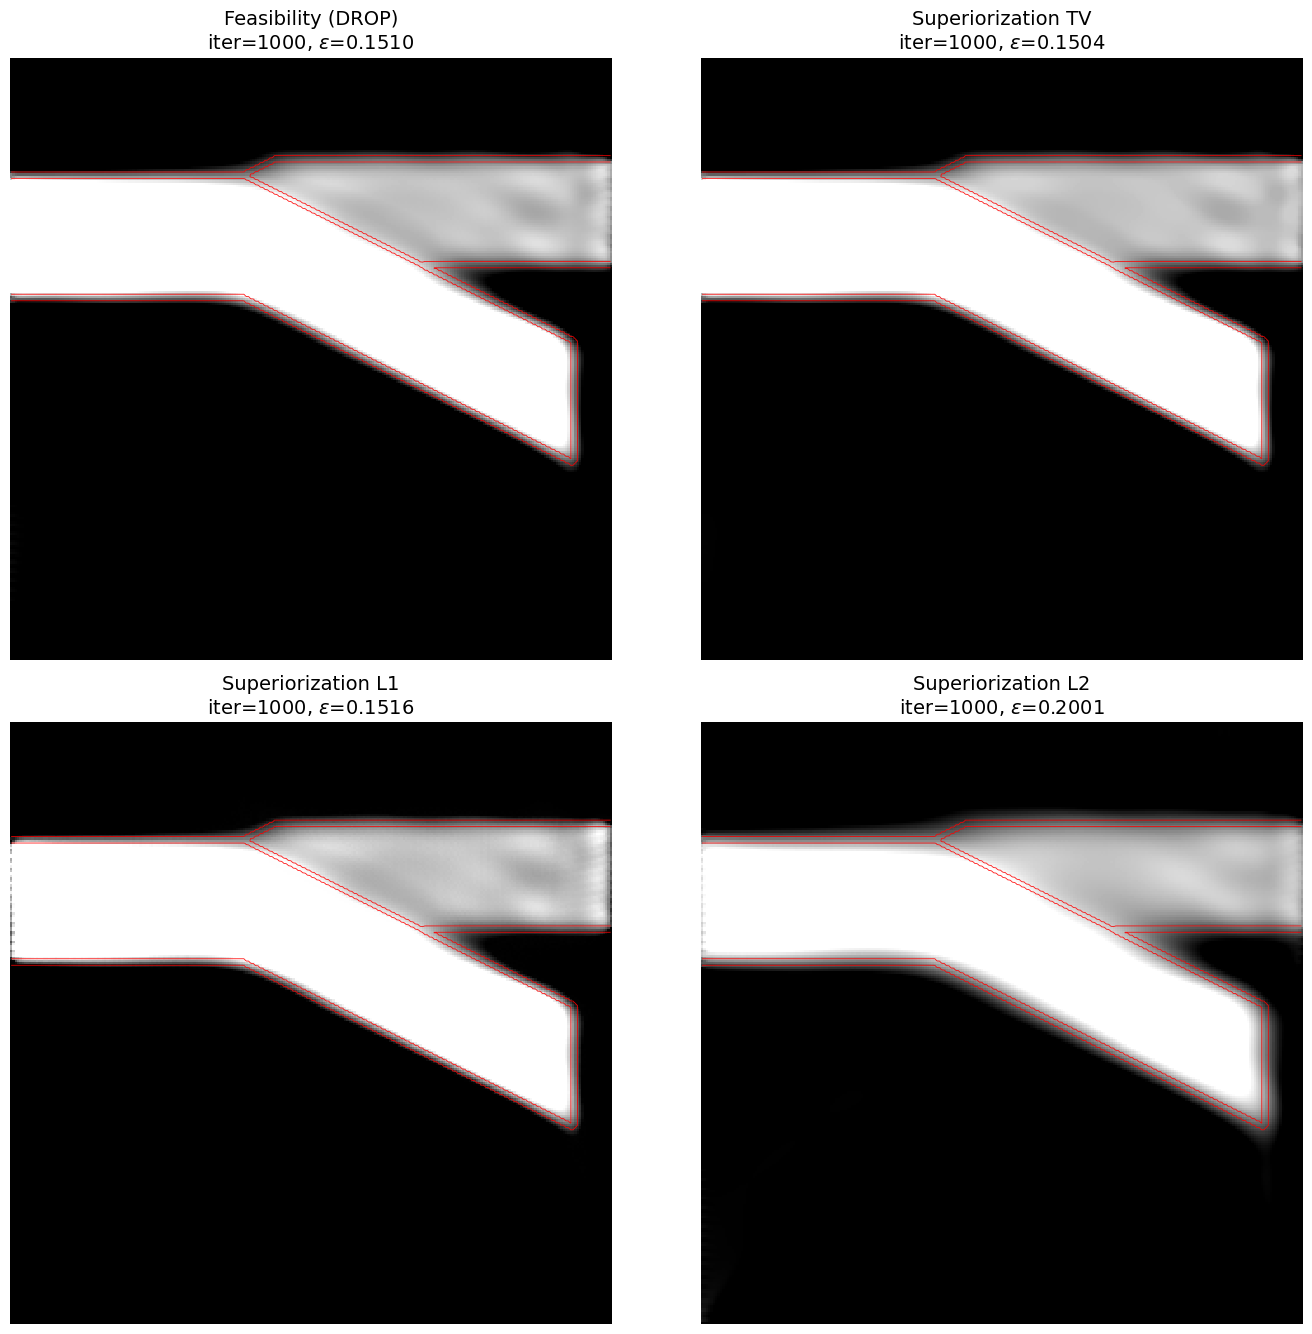

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 14))

i_feas = rel_errors_drop_feasibility.argmin()
i_sup  = rel_errors_drop_sup.argmin()
i_l1   = rel_errors_drop_sup_l1.argmin()
i_l2   = rel_errors_drop_sup_l2.argmin()

imgs = [
    (alg_drop_feasibility.all_x[i_feas],  f"Feasibility (DROP)\niter={i_feas}, $\epsilon$={rel_errors_drop_feasibility[i_feas]:.4f}"),
    (alg_drop_superiorization.all_x_basic[i_sup], f"Superiorization TV\niter={i_sup}, $\epsilon$={rel_errors_drop_sup[i_sup]:.4f}"),
    (alg_drop_superiorization_l1.all_x_basic[i_l1], f"Superiorization L1\niter={i_l1}, $\epsilon$={rel_errors_drop_sup_l1[i_l1]:.4f}"),
    (alg_drop_superiorization_l2.all_x_basic[i_l2], f"Superiorization L2\niter={i_l2}, $\epsilon$={rel_errors_drop_sup_l2[i_l2]:.4f}")
]

# true image and contour for edge overlay
true_img = true_sol.reshape(256,256).T
gy, gx = np.gradient(true_img)
edge = np.hypot(gx, gy)
edge_level = edge.max() * 0.08

vmin, vmax = 0.0, 1.0  

for ax, (img, title) in zip(axs.ravel(), imgs):
    arr = np.array(img).reshape(256, 256).T
    im = ax.imshow(arr, cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.contour(edge, levels=[edge_level], colors='r', linewidths=0.6, alpha = 0.9)
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('seismic_tomography_clean_reconstructions.png', dpi=600)
plt.show()


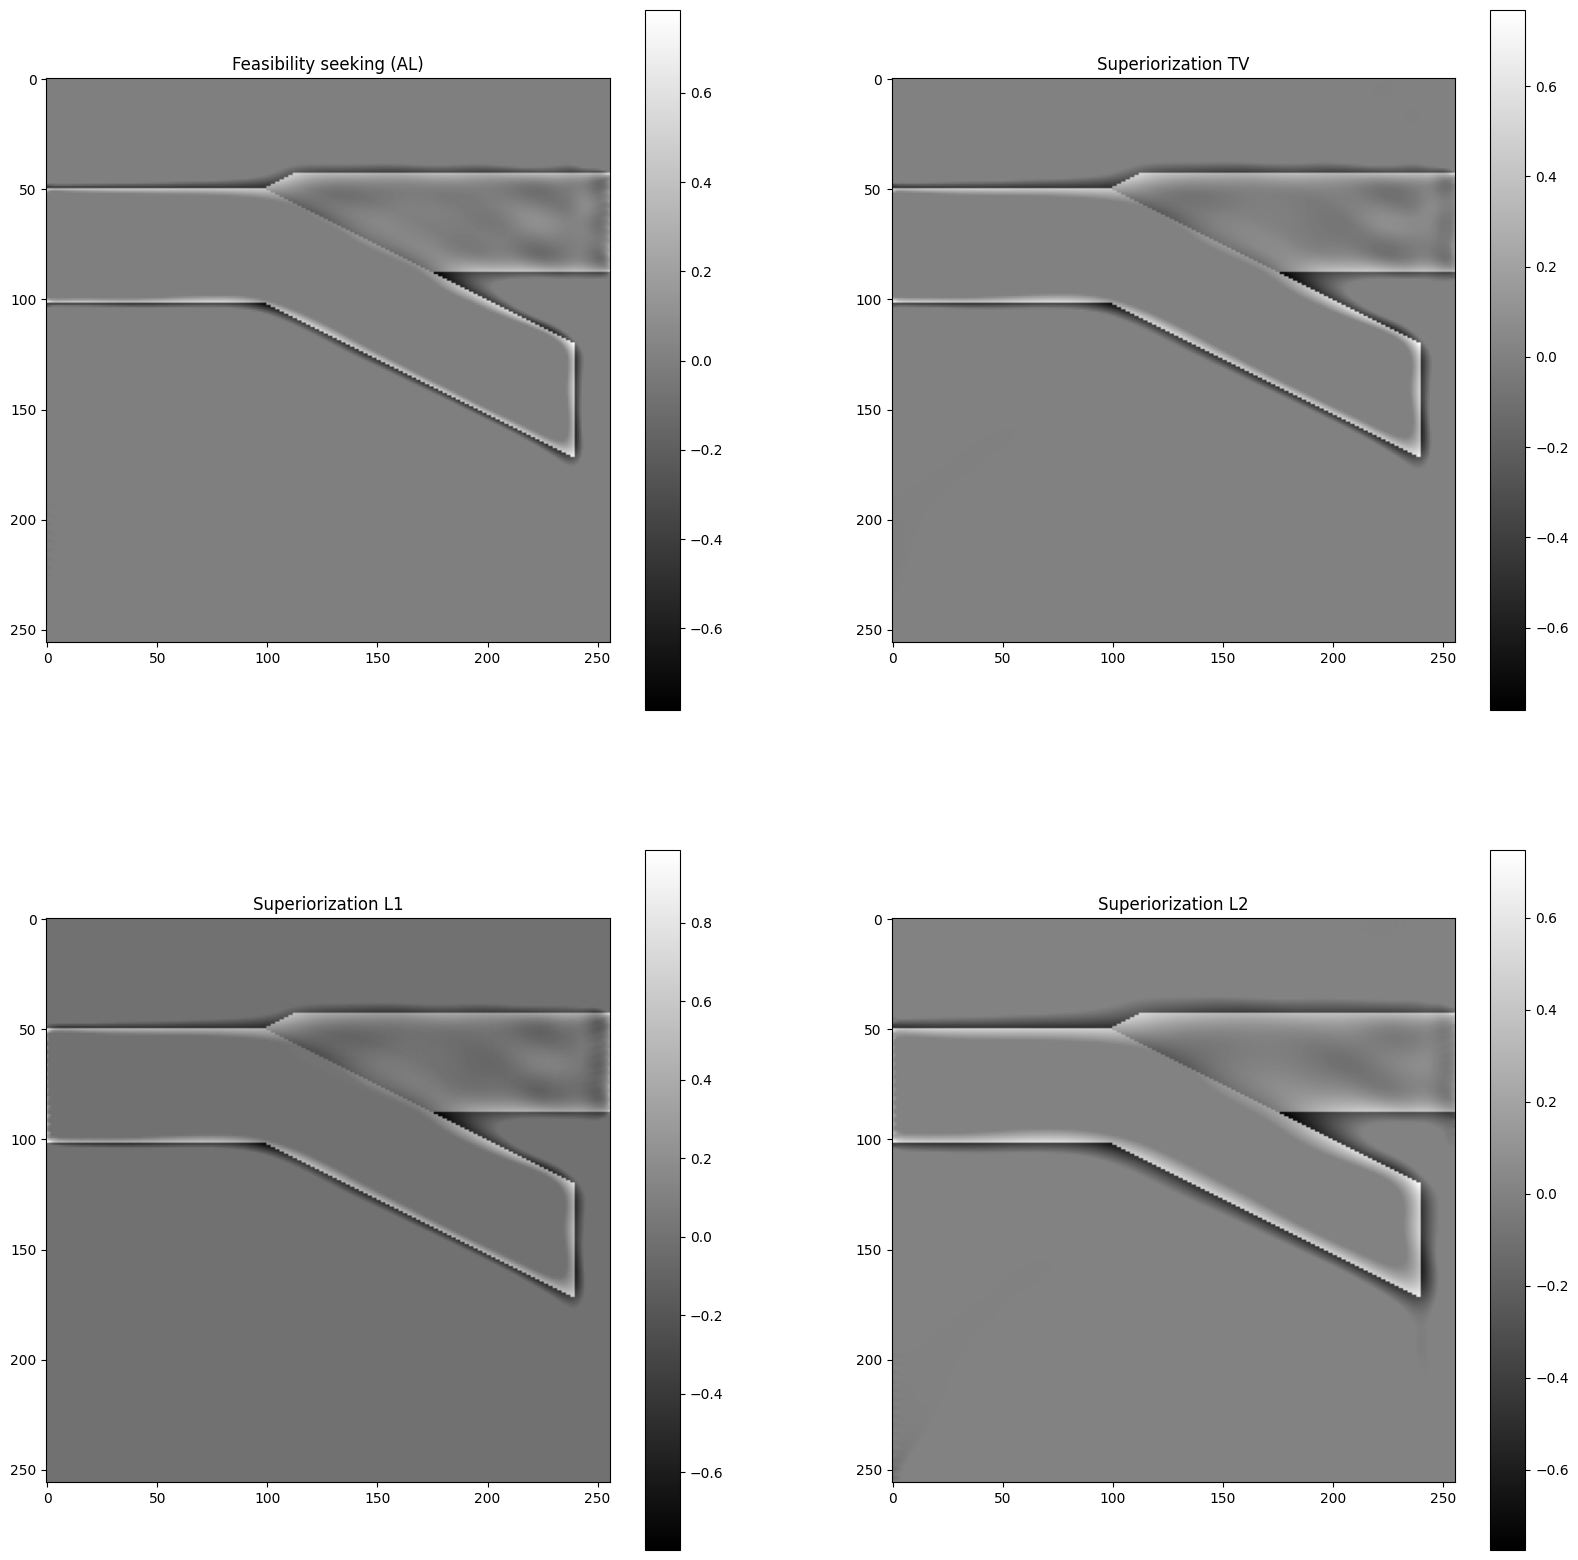

In [14]:

plt.figure(figsize=(20, 20))

# Plot true_sol
plt.subplot(2, 2, 1)
plt.title("Feasibility seeking (AL)")
plt.imshow(true_sol.reshape(256, 256).T - alg_drop_feasibility.all_x[rel_errors_drop_feasibility.argmin()].reshape(256, 256).T, cmap='gray')
plt.colorbar()


plt.subplot(2, 2, 2)
plt.title("Superiorization TV")
plt.imshow(true_sol.reshape(256, 256).T - alg_drop_superiorization.all_x[rel_errors_drop_sup.argmin()].reshape(256, 256).T, cmap='gray')
plt.colorbar()

plt.subplot(2, 2, 3)
plt.title("Superiorization L1")
plt.imshow(true_sol.reshape(256, 256).T - alg_drop_superiorization_l1.all_x[rel_errors_drop_sup_l1.argmin()].reshape(256, 256).T, cmap='gray')

plt.colorbar()
plt.subplot(2, 2, 4)
plt.title("Superiorization L2")
plt.imshow(true_sol.reshape(256, 256).T - alg_drop_superiorization_l2.all_x[rel_errors_drop_sup_l2.argmin()].reshape(256, 256).T, cmap='gray')
plt.colorbar()

In [15]:
## Relative errors
x_drop = data['Xdrop']
rel_errors_x_drop = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in x_drop.T])

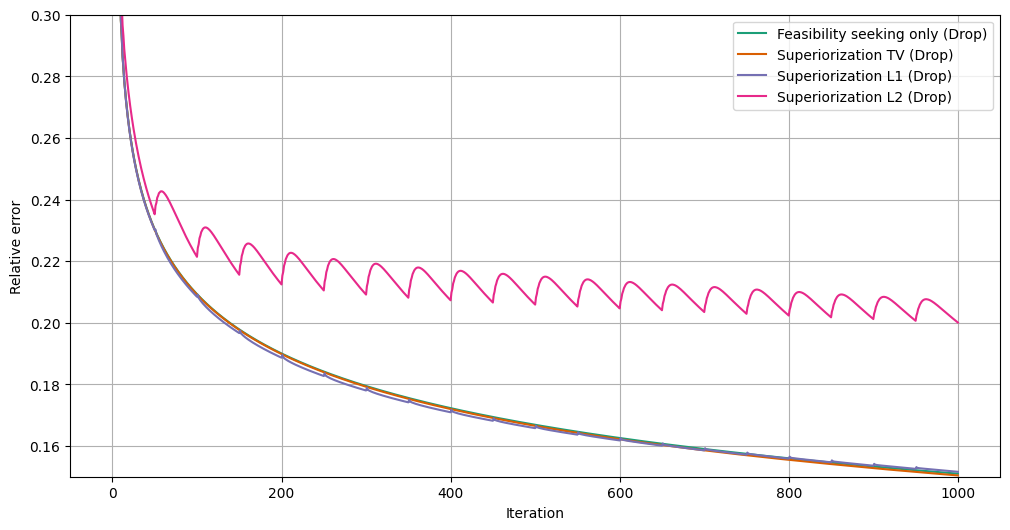

In [16]:
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a']
plt.figure(figsize=(12,6))
rel_errors_drop_feasibility = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_feasibility.all_x])
rel_errors_drop_sup = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization.all_x_basic])
rel_errors_drop_sup_l1 = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_l1.all_x_basic])
rel_errors_drop_sup_l2 = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_l2.all_x_basic])
plt.plot(rel_errors_drop_feasibility, label='Feasibility seeking only (Drop)',color = colors[0])
plt.plot(rel_errors_drop_sup, label='Superiorization TV (Drop)', color = colors[1])
plt.plot(rel_errors_drop_sup_l1, label='Superiorization L1 (Drop)', color = colors[2])
plt.plot(rel_errors_drop_sup_l2, label='Superiorization L2 (Drop)', color = colors[3])

#lt.yscale('log')
plt.legend()
plt.ylabel('Relative error')
plt.xlabel('Iteration')
plt.grid()
plt.ylim(0.15,0.3)
#plt.yscale('log')
plt.show()


In [17]:
print('Feasibility seeking:', rel_errors_drop_feasibility.min())
print('Superiorization TV:', rel_errors_drop_sup.min())
print('Superiorization L1:', rel_errors_drop_sup_l1.min())
print('Superiorization L2:', rel_errors_drop_sup_l2.min())

Feasibility seeking: 0.15098970522714458
Superiorization TV: 0.15041900508549397
Superiorization L1: 0.1515978426201383
Superiorization L2: 0.20006266948300266


## Run with noisy data

In [18]:
h = alg_drop_feasibility.project(x0.copy())#,proximity_measures= [("p_norm",2),"max_norm"])

In [19]:
b_noisy = data['b_noise'].T[0]
b_noisy_cp = cp.array(b_noisy)

alg_drop_feasibility_noisy = SequentialProjection([DROPHyperplane(A_cp, b_noisy_cp,algorithmic_relaxation = 2.916347327737711), BoxProjection(0, 1)])
sol_drop_feasibility_noisy = alg_drop_feasibility_noisy.solve(x0.copy(),max_iter = 1000, storage = True)


In [20]:

obj_cp = TV_Objective(N=256)
orth_proj = BoxProjection(0,1)

pert_drop_noisy = PowerSeriesGradientPerturbation(obj_cp.objective,obj_cp.gradient,step_size = 0.975,n_restart= 50, n_red = 4)

alg_drop_superiorization_noisy = Superiorization(alg_drop_feasibility_noisy, pert_drop_noisy)
sol_drop_superiorization_noisy = alg_drop_superiorization_noisy.solve(x0.copy(), max_iter=1000, storage = True)

In [21]:

pert_drop_l1_noisy = PowerSeriesGradientPerturbation(l1_norm, l1_gradient,step_size = 0.975,n_restart= 50, n_red = 4)
#alg_al = SequentialProjection([AdaptiveStepLandweberHyperplane(A_cp, cp.asarray(b_noisy)),orth_proj])
alg_drop_superiorization_l1_noisy = Superiorization(alg_drop_feasibility_noisy,pert_drop_l1_noisy)
sol_drop_superiorization_l1_noisy = alg_drop_superiorization_l1_noisy.solve(cp.zeros(A_cp.shape[1]),max_iter = 1000,proximity_measures = [("p_norm",2),"max_norm"],storage = True)

In [22]:

pert_drop_l2_noisy = PowerSeriesGradientPerturbation(l2_norm, l2_gradient,step_size = 0.975,n_restart= 50, n_red = 4)
#alg_al = SequentialProjection([AdaptiveStepLandweberHyperplane(A_cp, cp.asarray(b_noisy)),orth_proj])
alg_drop_superiorization_l2_noisy = Superiorization(alg_drop_feasibility_noisy,pert_drop_l2_noisy)
sol_drop_superiorization_l2_noisy = alg_drop_superiorization_l2_noisy.solve(cp.zeros(A_cp.shape[1]),max_iter = 1000,proximity_measures = [("p_norm",2),"max_norm"],storage = True)

In [23]:
true_sol = data['x'].flatten()
rel_errors_drop_feasibility_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_feasibility_noisy.all_x])
rel_errors_drop_sup_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_noisy.all_x_basic])
rel_errors_drop_sup_l1_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_l1_noisy.all_x_basic])
rel_errors_drop_sup_l2_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_l2_noisy.all_x_basic])

## Visualize results

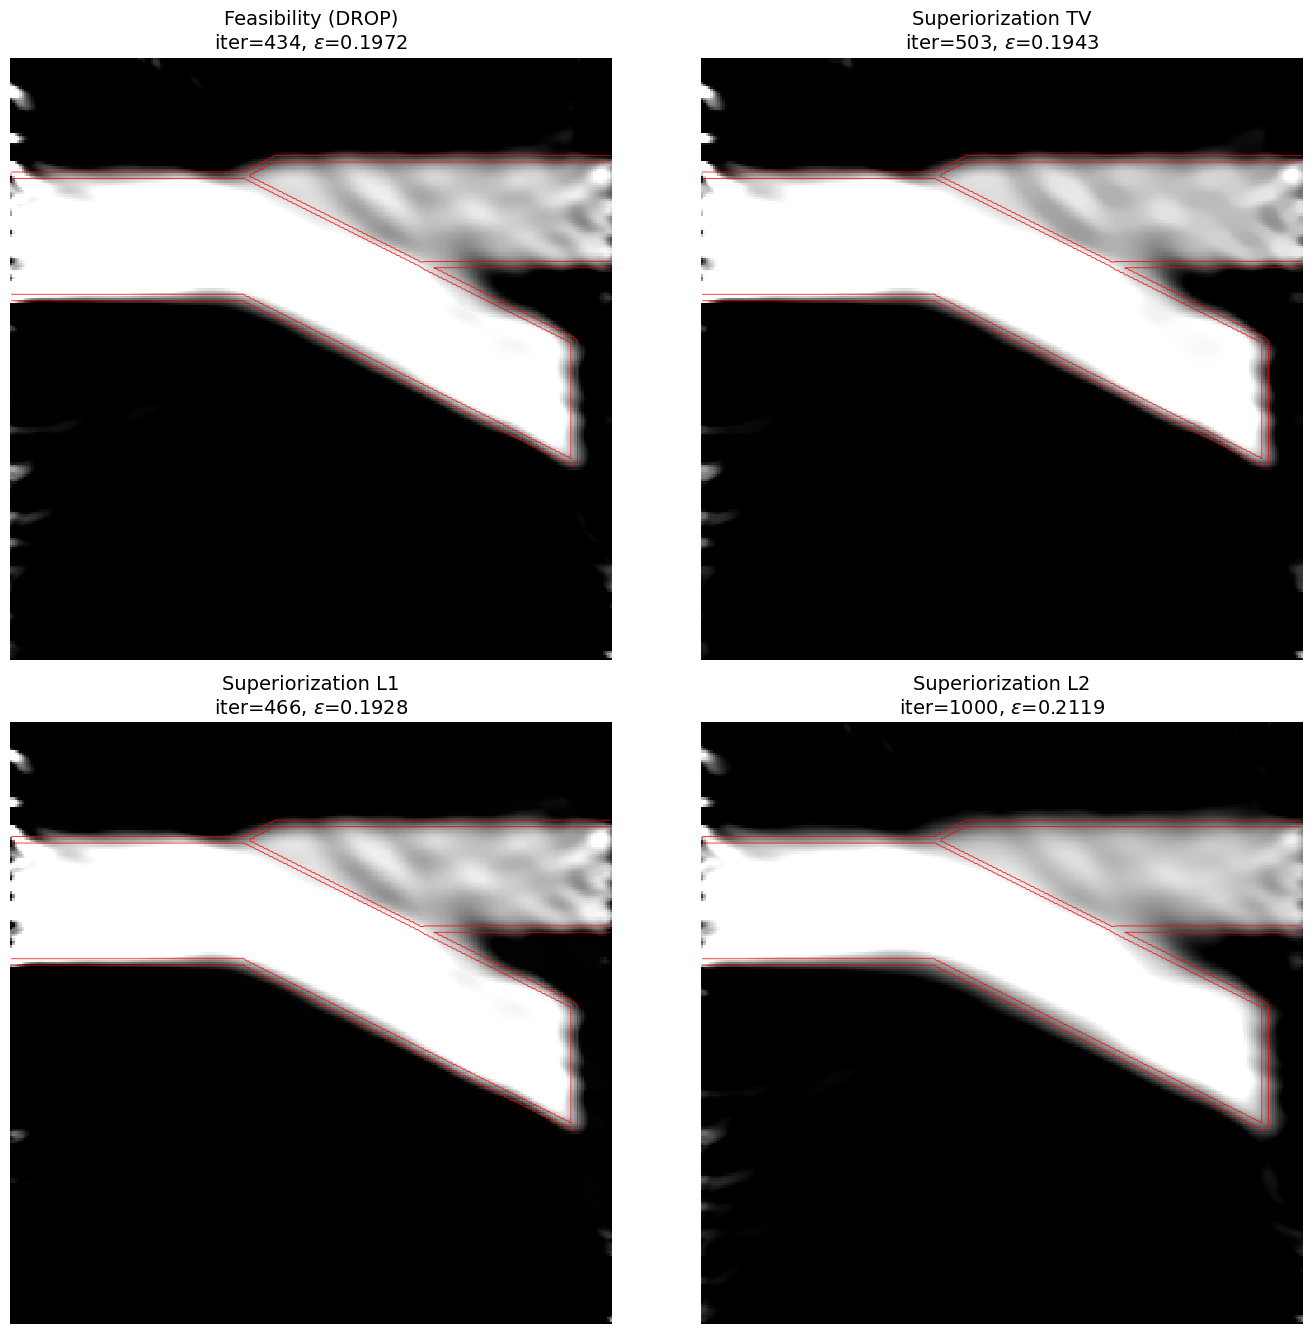

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 14))

i_feas = rel_errors_drop_feasibility_noisy.argmin()
i_sup  = rel_errors_drop_sup_noisy.argmin()
i_l1   = rel_errors_drop_sup_l1_noisy.argmin()
i_l2   = rel_errors_drop_sup_l2_noisy.argmin()

imgs = [
    (alg_drop_feasibility_noisy.all_x[i_feas],  f"Feasibility (DROP)\niter={i_feas}, $\epsilon$={rel_errors_drop_feasibility_noisy[i_feas]:.4f}"),
    (alg_drop_superiorization_noisy.all_x_basic[i_sup], f"Superiorization TV\niter={i_sup}, $\epsilon$={rel_errors_drop_sup_noisy[i_sup]:.4f}"),
    (alg_drop_superiorization_l1_noisy.all_x_basic[i_l1], f"Superiorization L1\niter={i_l1}, $\epsilon$={rel_errors_drop_sup_l1_noisy[i_l1]:.4f}"),
    (alg_drop_superiorization_l2_noisy.all_x_basic[i_l2], f"Superiorization L2\niter={i_l2}, $\epsilon$={rel_errors_drop_sup_l2_noisy[i_l2]:.4f}")
]

true_img = true_sol.reshape(256,256).T
gy, gx = np.gradient(true_img)
edge = np.hypot(gx, gy)
edge_level = edge.max() * 0.08

vmin, vmax = 0.0, 1.0 

for ax, (img, title) in zip(axs.ravel(), imgs):
    arr = np.array(img).reshape(256, 256).T
    im = ax.imshow(arr, cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.contour(edge, levels=[edge_level], colors='r', linewidths=0.6, alpha=0.9)  # true-solution edges
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('seismic_tomography_noisy_reconstructions.png', dpi=600)
plt.show()


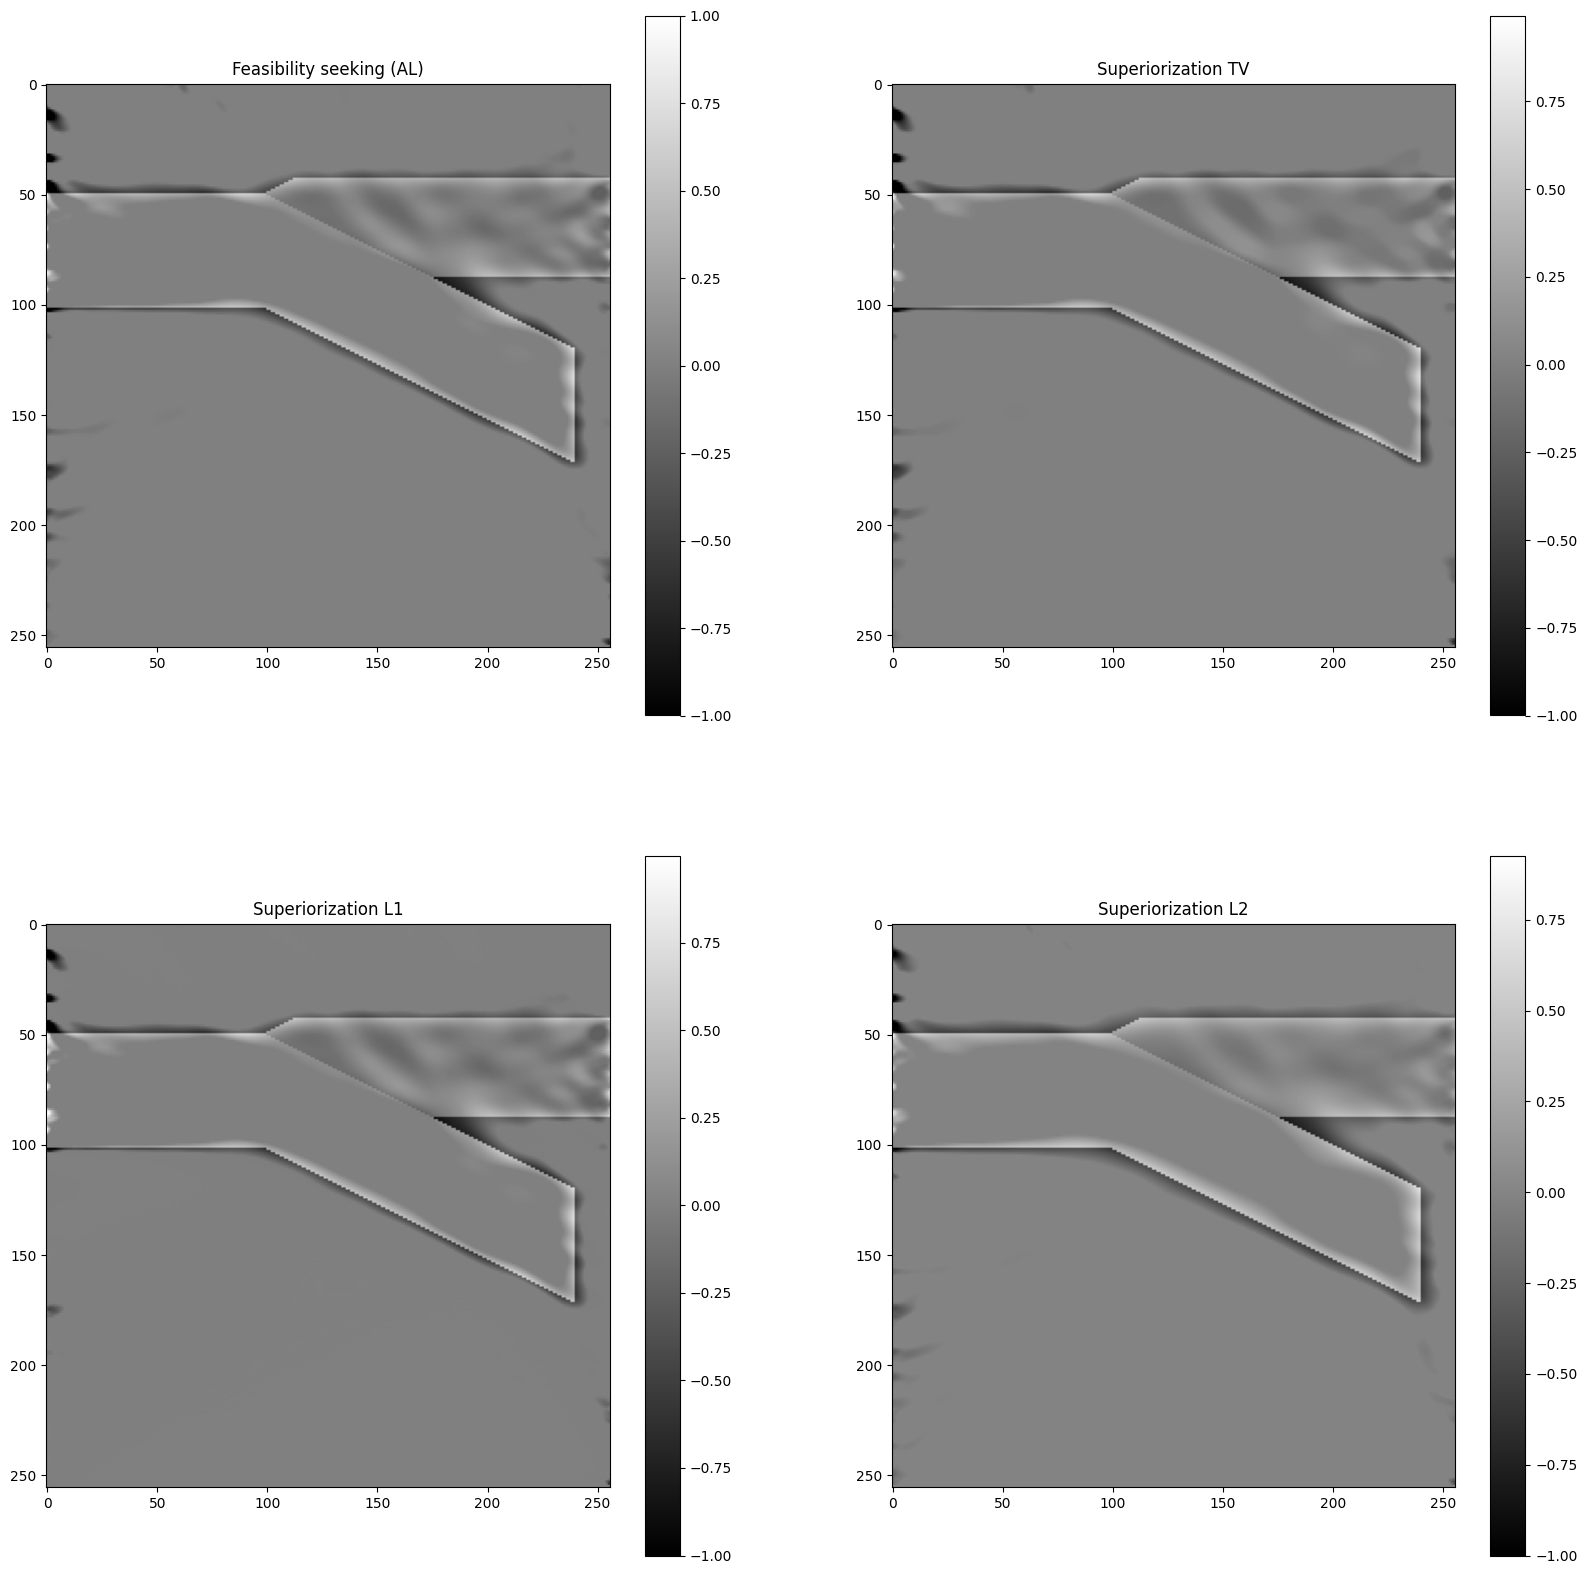

In [25]:

plt.figure(figsize=(20, 20))

# Plot true_sol
plt.subplot(2, 2, 1)
plt.title("Feasibility seeking (AL)")
plt.imshow(true_sol.reshape(256, 256).T - alg_drop_feasibility_noisy.all_x[rel_errors_drop_feasibility_noisy.argmin()].reshape(256, 256).T, cmap='gray')
plt.colorbar()


plt.subplot(2, 2, 2)
plt.title("Superiorization TV")
plt.imshow(true_sol.reshape(256, 256).T - alg_drop_superiorization_noisy.all_x_basic[rel_errors_drop_sup_noisy.argmin()].reshape(256, 256).T, cmap='gray')
plt.colorbar()

plt.subplot(2, 2, 3)
plt.title("Superiorization L1")
plt.imshow(true_sol.reshape(256, 256).T - alg_drop_superiorization_l1_noisy.all_x_basic[rel_errors_drop_sup_l1_noisy.argmin()].reshape(256, 256).T, cmap='gray')

plt.colorbar()
plt.subplot(2, 2, 4)
plt.title("Superiorization L2")
plt.imshow(true_sol.reshape(256, 256).T - alg_drop_superiorization_l2_noisy.all_x_basic[rel_errors_drop_sup_l2_noisy.argmin()].reshape(256, 256).T, cmap='gray')
plt.colorbar()

In [26]:
## Relative errors
x_drop_noisy = data['Xdrop_noise']
rel_errors_x_drop_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in x_drop_noisy.T])

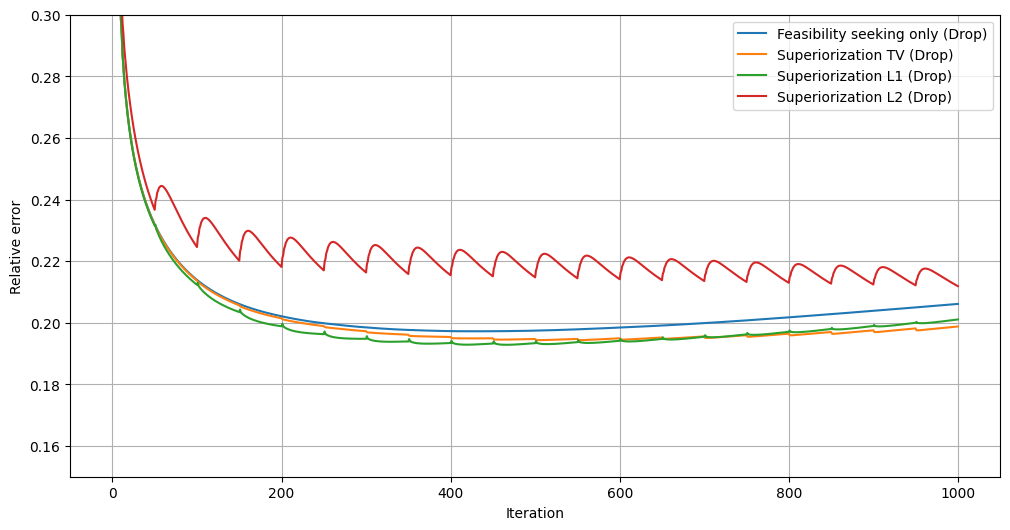

In [27]:
plt.figure(figsize=(12,6))
rel_errors_drop_feasibility_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_feasibility_noisy.all_x])
rel_errors_drop_sup_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_noisy.all_x_basic])
rel_errors_drop_sup_l1_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_l1_noisy.all_x_basic])
rel_errors_drop_sup_l2_noisy = np.array([np.linalg.norm(x_el - np.array(true_sol)) / (np.linalg.norm(true_sol)) for x_el in alg_drop_superiorization_l2_noisy.all_x_basic])
plt.plot(rel_errors_drop_feasibility_noisy, label='Feasibility seeking only (Drop)')
plt.plot(rel_errors_drop_sup_noisy, label='Superiorization TV (Drop)')
plt.plot(rel_errors_drop_sup_l1_noisy, label='Superiorization L1 (Drop)')
plt.plot(rel_errors_drop_sup_l2_noisy, label='Superiorization L2 (Drop)')

#lt.yscale('log')
plt.legend()
plt.ylabel('Relative error')
plt.xlabel('Iteration')
plt.grid()
plt.ylim(0.15,0.3)
#plt.yscale('log')
plt.show()


In [28]:
print('Feasibility seeking:', rel_errors_drop_feasibility_noisy.min())
print('Superiorization TV:', rel_errors_drop_sup_noisy.min())
print('Superiorization L1:', rel_errors_drop_sup_l1_noisy.min())
print('Superiorization L2:', rel_errors_drop_sup_l2_noisy.min())

Feasibility seeking: 0.19722247965725534
Superiorization TV: 0.19433729198565702
Superiorization L1: 0.192839086078502
Superiorization L2: 0.2118717540034838


## Visualize results

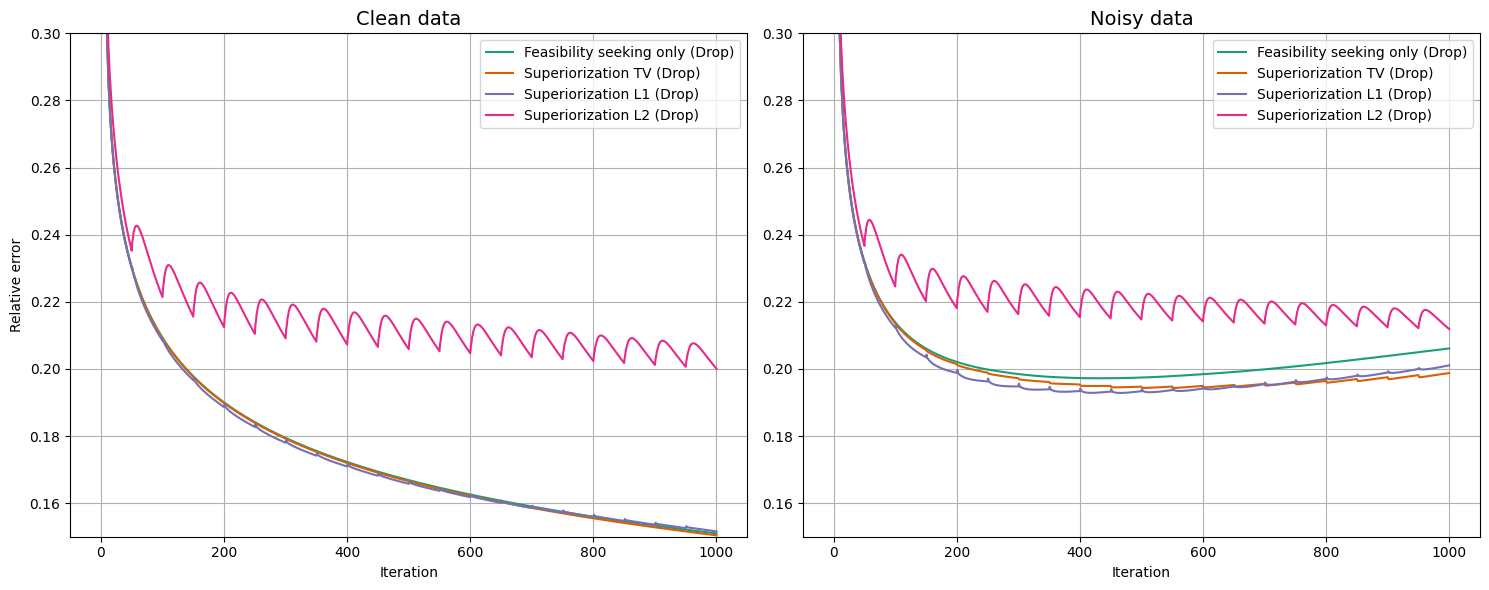

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#1b9e77','#d95f02','#7570b3','#e7298a']

# Left: clean data
axs[0].plot(rel_errors_drop_feasibility, label='Feasibility seeking only (Drop)', color = colors[0])
axs[0].plot(rel_errors_drop_sup, label='Superiorization TV (Drop)', color = colors[1])
axs[0].plot(rel_errors_drop_sup_l1, label='Superiorization L1 (Drop)', color = colors[2])
axs[0].plot(rel_errors_drop_sup_l2, label='Superiorization L2 (Drop)', color = colors[3])
axs[0].set_title('Clean data', fontsize = 14 )
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Relative error')
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(0.15, 0.3)

# Right: noisy data
axs[1].plot(rel_errors_drop_feasibility_noisy, label='Feasibility seeking only (Drop)', color = colors[0])
axs[1].plot(rel_errors_drop_sup_noisy, label='Superiorization TV (Drop)', color = colors[1])
axs[1].plot(rel_errors_drop_sup_l1_noisy, label='Superiorization L1 (Drop)', color = colors[2])
axs[1].plot(rel_errors_drop_sup_l2_noisy, label='Superiorization L2 (Drop)', color = colors[3])
axs[1].set_title('Noisy data', fontsize = 14 )
axs[1].set_xlabel('Iteration')
axs[1].legend()
axs[1].grid()
axs[1].set_ylim(0.15, 0.3)

plt.tight_layout()
plt.savefig('seismic_tomography_comparison_rel_errors.png', dpi=300)
plt.show()
